In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt 
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

In [2]:
# Python image Library (PIL) -> tensor
transform = transforms.Compose([transforms.ToTensor()])

In [3]:
# Getting MNIST data as PIL
training_dataset =  torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform) 
val_dataset = torchvision.datasets.MNIST(root="./data",train=False, download=True, transform=transform)

In [4]:
# configs for ViT according to simle MNIST dataset
batch_size = 64
num_classes = 10
num_channels = 1 
img_size = 28
patch_size = 7 
patch_num = (img_size // patch_size) ** 2 
num_attention_heads = 4
embedding_dim = 16
num_transformer_block = 4
feed_forward_neural_network_nodes = 64
learning_rate = 0.001
epochs = 5

In [5]:
# Dataloaders to transfer data into batches
training_data = dataloader.DataLoader(training_dataset, shuffle=True, batch_size=64)
val_data = dataloader.DataLoader(val_dataset, shuffle=True , batch_size=64)

In [6]:
# Part 1 - patch Embeddings
class PatchEmbedding(nn.Module):
    """
    Class for generate patchEmbeddings from according to the patch_size
    """
    def __init__(self):
        super().__init__()

        # We are just getting the values of the patches with conv2d , no CNN is used
        self.patch_embed = nn.Conv2d(num_channels , embedding_dim , kernel_size= patch_size, stride=patch_size)


    def forward(self, x):
        """
            takes a batch and converts it into patch_embeddings ready to feed into transformer encoder
        """

        # input image shape = [64 , 1 , 28 , 28] 
        #                   (batch , channels , height , width)
        x = self.patch_embed(x)

        # patch_embed gives [64 , 24 , 4 , 4]
        #                   (batch , embedding_dim , patch_in_y , patch_in_x)
        
        # flatten(2) gives [64,24,16] , fattens 4 * 4 patches into one
        x = x.flatten(2)

        # transpose(1,2) gives [64,16,24]
        x = x.transpose(1,2)
        return x 

In [7]:
# Part 2 - Transformer encoder
# Layer Normalization
# Multi-Head Attention
# Layer Normalization 
# residuals
# FFNN

class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embedding_dim)

        # if batch_first is not true then the dimensions are mistakes and accuracy drops from 90% -> 10% 
        self.self_attention = nn.MultiheadAttention(embedding_dim,num_attention_heads,batch_first=True)
        self.layer_norm_2 = nn.LayerNorm(embedding_dim)
        self.feed_Forward_Neural_Network = nn.Sequential(
            nn.Linear(embedding_dim,feed_forward_neural_network_nodes), 
            # smoother version of relu at 0
            nn.GELU(),
            nn.Linear(feed_forward_neural_network_nodes , embedding_dim)
        )


    def forward(self , x):
        """
            coding the transformer encoder according the architecture in the image.
        """
        # saving the original patch_embedding
        residual_1 = x 
        x = self.layer_norm_1(x)
        # 3 inputs for Q , K , V
        x = self.self_attention(x,x,x)[0] + residual_1
        residual_2 = x 
        x = self.layer_norm_2(x)
        x  = self.feed_Forward_Neural_Network(x) + residual_2

        return x

In [24]:
# Part 3 - FFNN head for classification

class FFNN_Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.feed_Forward_Neural_Network = nn.Sequential(
            nn.Linear(embedding_dim, feed_forward_neural_network_nodes),
            nn.GELU(),
            nn.Linear(feed_forward_neural_network_nodes, embedding_dim)
        )


    def forward(self , x):
        # x = x[:,0]
        x = self.feed_Forward_Neural_Network(x)
        return x 
        



In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embedding = PatchEmbedding()
        # classification token at the start
        self.cls_token = nn.Parameter(torch.randn(1,1,embedding_dim))

        # plus because pos embedding is also added to cls token 
        self.pos_emd = nn.Parameter(torch.randn(1, patch_num + 1,embedding_dim))

        self.transformer_layers = nn.Sequential(* [TransformerEncoder() for _ in range(num_transformer_block)])
        self.ffnn_head = FFNN_Head()


    def forward(self,x ):
        x = self.patch_embedding(x)
        batch = x.size(0)

        # cls token is copied batch times , -1 ,-1 makes sure that other dimensions are kept as they were 
        cls_tokens = self.cls_token.expand(batch,-1,-1)

        # concatinate at the beginning 
        x = torch.cat((cls_tokens,x),dim=1)
        x = x + self.pos_emd
        x = self.transformer_layers(x)
        x = x[:,0]
        x = self.ffnn_head(x)
        return x

In [26]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# move model to gpu
model = VisionTransformer().to(device)


# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)




# crossEntropy
criterion = nn.CrossEntropyLoss()

In [29]:


for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0

    for batch_idx , (images,labels) in enumerate(training_data):


        images , labels = images.to(device) , labels.to(device)

        # forgets gradients of previous batch if there
        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output,labels)
        loss.backward()


        optimizer.step()



        total_loss += loss.item()

        # Getting the highest propababilities from each output
        preds  = output.argmax(dim=1)

        correct  = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)


        # Adds the current correctness and number of batches for epoch level accuracy 
        correct_epoch += correct
        total_epoch += labels.size(0)


        # printing average loss and accuracy after 100 batches in epochs
        if batch_idx % 100 == 0:
            print(f" Batch {batch_idx+1:3d}: loss = {loss.item():.4f} , Accuracy = {accuracy:.2f}%")

    # prints epoch level accuracy
    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}")

 Batch   1: loss = 2.7484 , Accuracy = 4.69%
 Batch 101: loss = 1.8211 , Accuracy = 28.12%
 Batch 201: loss = 0.7231 , Accuracy = 75.00%
 Batch 301: loss = 0.8311 , Accuracy = 73.44%
 Batch 401: loss = 0.5736 , Accuracy = 78.12%
 Batch 501: loss = 0.4617 , Accuracy = 85.94%
 Batch 601: loss = 0.4025 , Accuracy = 81.25%
 Batch 701: loss = 0.2562 , Accuracy = 92.19%
 Batch 801: loss = 0.6111 , Accuracy = 79.69%
 Batch 901: loss = 0.1838 , Accuracy = 93.75%
==> Epoch 1 Summary: Total loss = 692.0646, Accuracy = 75.36
 Batch   1: loss = 0.4874 , Accuracy = 87.50%
 Batch 101: loss = 0.2914 , Accuracy = 90.62%
 Batch 201: loss = 0.4194 , Accuracy = 92.19%
 Batch 301: loss = 0.2362 , Accuracy = 92.19%
 Batch 401: loss = 0.2498 , Accuracy = 95.31%
 Batch 501: loss = 0.2257 , Accuracy = 93.75%
 Batch 601: loss = 0.1480 , Accuracy = 95.31%
 Batch 701: loss = 0.1920 , Accuracy = 92.19%
 Batch 801: loss = 0.1992 , Accuracy = 93.75%
 Batch 901: loss = 0.0947 , Accuracy = 93.75%
==> Epoch 2 Summary:

In [30]:
# accuracy on Validation data

model.eval() 
correct = 0 
total = 0 


with torch.no_grad():
    for images, labels in val_data:
        images , labels = images.to(device), labels.to(device)
        outputs = model(images)     
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

        total += labels.size(0)


val_acc = 100.0 * correct / total 
print(f"\n ==> Val Accuracy : {val_acc:.2f}")


 ==> Val Accuracy : 96.31


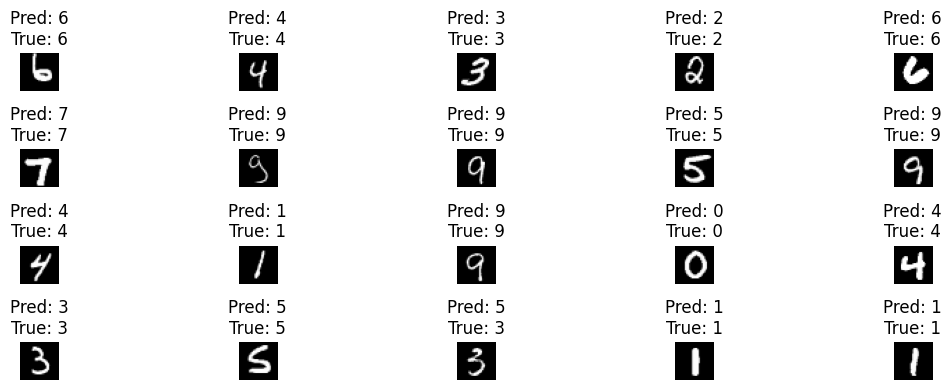

In [32]:
model.eval()
images, labels = next(iter(val_data))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze().cpu().numpy(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()